In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime as dt 
import matplotlib.pyplot as plt
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# Define the ticker symbol for the Shanghai Composite Index
ticker = '000001.SS'

# Define the date range
start_date = '2014-01-01'
end_date = '2024-01-01'

# Download the full dataset sourced from yahoo finance
data = yf.download(ticker, start=start_date, end=end_date)

print(pd.concat([data.head(1), data.tail(1)]))


[*********************100%%**********************]  1 of 1 completed

                   Open         High          Low        Close    Adj Close  \
Date                                                                          
2014-01-02  2112.125977  2113.110107  2101.016113  2109.386963  2109.386963   
2023-12-29  2950.836914  2975.031982  2950.017090  2974.935059  2974.935059   

            Volume  
Date                
2014-01-02   68500  
2023-12-29  290700  


In [3]:
# Extract close price as our target data, denoted by X
X = data.Close

# Perform the Augmented Dickey-Fuller (ADF) test to check if the time series is stationary
result = adfuller(X)
# Print the test statistic - a more negative value indicates a higher likelihood of stationarity
print('Dickey-Fuller Statistic: %f' % result[0])
# Print the p-value - a lower value (typically < 0.05) means we can reject the null hypothesis of non-stationarity
print('p-value: %f' % result[1])
# Print the critical values at different confidence levels (1%, 5%, and 10%) - the thresholds for the test statistic
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# Perform the Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test to check if the time series is stationary
result_kpss = kpss(X, regression='c')
# Print the KPSS test statistic - a higher value indicates a higher likelihood of non-stationarity
print('KPSS Statistic: %f' % result_kpss[0])
# Print the p-value - a higher value (typically > 0.05) means we cannot reject the null hypothesis of stationarity
print('p-value: %f' % result_kpss[1])
# Print the critical values at different confidence levels (10%, 5%, 2.5%, and 1%) - the thresholds for the test statistic
print('Critical Values:')
for key, value in result_kpss[3].items():
    print('\t%s: %.3f' % (key, value))

Dickey-Fuller Statistic: -3.124732
p-value: 0.024776
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567
KPSS Statistic: 0.802910
p-value: 0.010000
Critical Values:
	10%: 0.347
	5%: 0.463
	2.5%: 0.574
	1%: 0.739


c:\Users\p0f3h\anaconda3\envs\2024project\lib\site-packages\statsmodels\tsa\stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(


In [4]:
# Define a function for train-test split
def train_test_split(X, size=0.9):
    train = X[:int(X.shape[0]*size)]
    test = X[int(X.shape[0]*size):]
    return train, test

# Split train set and test set
train, test = train_test_split(X=data['Close'], size=0.9)

In [5]:
# Train an ARIMA model using the auto_arima function on the training data
arima_model = auto_arima(train, trace=True, error_action='ignore', suppress_warnings=True)

# Print a summary of the fitted ARIMA model
print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=22799.542, Time=1.52 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=22865.142, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=22858.123, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=22856.954, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=22863.357, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=22855.182, Time=0.30 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=22854.259, Time=0.35 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=22779.514, Time=1.71 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=22850.379, Time=0.77 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=22781.262, Time=1.38 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=2.04 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=22861.508, Time=1.54 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=22839.624, Time=0.47 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=22783.030, Time=1.82 sec
 ARIMA(3,1,2)(0,0,0)[0]  

In [24]:
# Extract residuals from ARIMA model
arima_residuals = arima_model.resid()

# Define EGARCH model function
def egarch_model(data, p=1, o=1, q=1, mean='constant', dist='normal'):
    model = arch_model(
        data, 
        p=p, o=o, q=q, 
        mean=mean, 
        vol='EGARCH', 
        dist=dist
    )
    return model

# Function to fit EGARCH model and return AIC and BIC
def fit_egarch_model(data, p, o, q, mean='constant', dist='normal'):
    model = arch_model(
        data,
        p=p, o=o, q=q,
        mean=mean,
        vol='EGARCH',
        dist=dist
    )
    results = model.fit(disp='off')
    return results.aic, results.bic

# Determine the optimal o value
aic_values = []
bic_values = []
max_lags = 8  # Set a reasonable upper limit for lag order
for o in range(1, max_lags + 1):
    aic, bic = fit_egarch_model(arima_residuals, p=1, o=o, q=1)
    aic_values.append(aic)
    bic_values.append(bic)

# Find the o value with the better AIC and BIC
optimal_o_aic = np.argmin(aic_values) + 1
optimal_o_bic = np.argmin(bic_values) + 1

print(f'Optimal o based on AIC: {optimal_o_aic}')
print(f'Optimal o based on BIC: {optimal_o_bic}')

# Apply EGARCH model to ARIMA residuals with optimal o
optimal_o = optimal_o_bic  # or optimal_o_aic based on preference
EGARCH = egarch_model(arima_residuals, p=1, o=optimal_o, q=1)
# Fit the EGARCH model
egarch_results = EGARCH.fit(disp='off', show_warning=False)

# Display EGARCH model fitting summary
print(egarch_results.summary())

Optimal o based on AIC: 7
Optimal o based on BIC: 3
                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -14722.7
Distribution:                  Normal   AIC:                           29459.5
Method:            Maximum Likelihood   BIC:                           29501.5
                                        No. Observations:                 3015
Date:                Mon, Jul 22 2024   Df Residuals:                     3014
Time:                        13:49:47   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.6

In [25]:
# Function to perform one-step forecast
def one_step_forecast():
    arima_forecast, conf_int = arima_model.predict(n_periods=1, return_conf_int=True)
    egarch_forecast = egarch_results.forecast(horizon=1)
    return (
        arima_forecast.tolist()[0],
        np.asarray(conf_int).tolist()[0],
        egarch_forecast.variance.values[-1, 0]  # Access the forecasted variance correctly
    )

arima_predictions = []
confidence_intervals = []
egarch_predictions = []

for x in test:
    arima_forecast, conf, egarch_forecast = one_step_forecast()
    arima_predictions.append(arima_forecast)
    confidence_intervals.append(conf)
    egarch_predictions.append(egarch_forecast)

    # Update the ARIMA model
    arima_model.update(x)
    arima_residuals = arima_model.resid()
    # Refit the EGARCH model with the updated data
    egarch_results = egarch_model(arima_residuals)
    egarch_results = egarch_results.fit(disp="off", show_warning=False)


MAE: 30.600487512149886
RMSE: 36.519807305379764
MAPE: 0.9648766962965285%


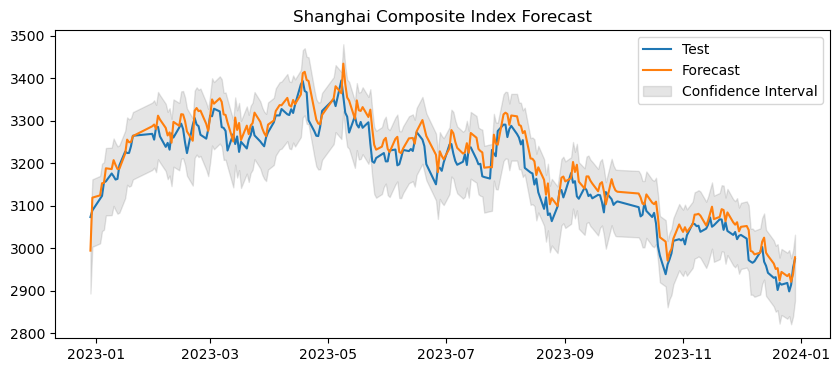

In [26]:
# Combine ARIMA and GARCH Forecasts
arima_forecast_series = pd.Series(arima_predictions, index=test.index)
conf_int_df = pd.DataFrame(confidence_intervals, index=test.index, columns=['lower', 'upper'])
egarch_forecast_series = pd.Series(egarch_predictions, index=test.index)

final_forecast = arima_forecast_series + np.sqrt(egarch_forecast_series)

# Evaluate the Forecast
mae = mean_absolute_error(test, final_forecast)
rmse = np.sqrt(mean_squared_error(test, final_forecast))
mape = np.mean(np.abs((test - final_forecast) / test)) * 100

# Print the evaluation metrics
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}%')

# Plot the results
plt.figure(figsize=(10, 4))
plt.plot(test, label='Test')
plt.plot(final_forecast, label='Forecast')
plt.fill_between(conf_int_df.index, conf_int_df['lower'], conf_int_df['upper'], color='k', alpha=0.1, label='Confidence Interval')
plt.title('Shanghai Composite Index Forecast')
plt.legend()
plt.show()